# Spectral analysis assignment (50 points)

In this assignment you will perform a set of operations involving spectra.  

**This assignment is due at noon on September 18.**  Your final version needs to be uploaded to your github repository by this time.

By the end of this activity you will have learned how to do the following things:
* Read in spectral files for stars
* determine the dispersion of the spectrograph in Angstrom/pixel
* plot the spectra of three stars
* measure $f_\lambda$ of each star at a specific wavelength.
* Given a frequency, derive $f_\nu$ at that frequency
* plot the filter curve of the B and V filters on top of the stellar spectra
* Calculate the B-V color of each star by convolving the spectrum with the appropriate filter curves.  compare to the published values.  During this step you will do the following calculations:
  * measure the magnitude using the central flux in each filter
  * Figure out your own way to estimate the color more accurately using the filter curve
  * repeat the same procedure using the speclite library (https://speclite.readthedocs.io/en/latest/index.html) to get the "correct" answer.
  * comment on the differences
  
Places where you need to fill in code will be indicated with a #### Write code here. If the part you have to enter is in the middle of a block of code the area that ends where you have to enter code will end with #---- Some of these will not be directly linked to points because they are simply bookkeeping things that depend on your own computer. Other sections that specify specific problems will be indicated with a  
### Problem
statement.  Please read everything carefully to find all the places you will need to enter code.

You will need to execute all blocks of code before handing this assignment in. You must include the appropriate level of significant digits in your answer.

**Comments are important**: You need to comment your code thoroughly so that I know what you did and why you did it. It will make it easier for me to give you credit. You should add comments in the code and also feel free to add new markdown cells with the format of the cell below.

<font color='red'> All answers in markdown cells are given in red</font>


## The spectral library

We will be using the <a href=https://www.noao.edu/cflib/>"Indo-US Spectral Atlas" </a> of bright stars.  I have downloaded two stellar spectra and they are included in my github repository.

In some of the code below, the explanation will be in the commented text within the code block, so make sure to read all of it.

## Importing modules, packages, and libraries

The first step will be to import the necessary components.

In [1]:
#This library stores filter response curves and contains functions to convolve them with spectra
import speclite.filters                         

#the library that allows you to read, store, and manipulate tables
from astropy.table import Table

#Pyplot is what we will use to make many of our plots.
from matplotlib import pyplot as plt

#allows you to execute commands directly to the operating system
import os           

#this is a useful python module that allows you to assign explicit units to numbers that 
#python uses to handle unit conversions and to perform calculations.  It can be a little
#hard to get used to but is very useful once you learn how to use it.
from astropy import units as u

#built-in physical constants
from astropy import constants as c

import numpy as np

## Reading in the Files 

The next step will be to read in the files.  I encourage you to open each of the \*.txt files that contain the stellar spectra.  We will read each text file into an "astropy Table".  These are described at https://docs.astropy.org/en/stable/table/index.html and are a useful way to read in and store text data.

### Problem 1 (5 points)
Complete the missing sections of the code.

In [2]:
#Use an OS command to get the path to your home directory
homedir = os.getenv("HOME")

#here you will need to specify the directory tree that points to your spectrum files.  
#This directory starts in your home directory so you don't need to type, e.g.  /home/<username>/
#In the commented code below I've shown you how I did it for my computer but you need to set it up for your computer.
#### Write code here
specdir = homedir+'/Work/Teaching/Classes/Astro_596/Fall_2023/Computer_projects/ASTR596_F23/Stellar-spectral-analysis/'

#this moves you to specdir so that you don't need to specify the path every time you read in a file.
os.chdir(specdir)

#this command reads the wavelength and flux of 95418.txt into a variable called star1.  
#The 'names' kwarg specifies the names of the columns
star1 = Table.read('95418.txt',format='ascii', names=('lambda','flam'))
display(star1)               #display the value of the table

#Now I would like you to read 58946.txt into a variable 'star2' and 165341.txt into a variable called star3.  
#Display the values for each table
#### Write code here
##star2 = Table.read('58946.txt',format='ascii', names=('lambda','flam'))
star3 = Table.read('165341.txt',format='ascii', names=('lambda','flam'))
##display(star2)               #display the value of the table
display(star3)               #display the value of the table

#-------
#The spectra are given normalized to flambda=1 erg/s/cm^2/Ang at lambda=5500
#We want to scale the flux of each star to have the same flux as Vega at 5500 Ang.
#At 5500 Ang, Vega has a flux of 3.44x10^(-9) erg/s/cm^2/Ang .  
#########remember that if you rerun your jupyter notebook that this operation will 
#########be executed over and over again.
fvega5500 = 3.44e-9
star1['flam'] *= fvega5500
star3['flam'] *= fvega5500

lambda,flam
float64,float64
3465.0,0.9348064
3465.4,0.9298626
3465.8,0.9295582
3466.2,0.9163543
3466.6,0.9428962
3467.0,0.9729065
3467.4,0.9731162
3467.8,0.965655
3468.2,0.9507776


lambda,flam
float64,float64
3465.0,0.3538652
3465.4,0.2905372
3465.8,0.2453179
3466.2,0.2475912
3466.6,0.2801426
3467.0,0.3293486
3467.4,0.373181
3467.8,0.3981356
3468.2,0.4190642


## Compute the dispersion of the spectra

### Problem 2 (5 points)

Using the print outs of the spectra above, enter the dispersion of each spectrum.  That is, what is the spacing in Angstroms between each adjacent flux point?

**Enter your answers here**
* <font color='red'>star 1: 0.4 Angstroms</font>
* <font color='red'>star 3: 0.4 Angstroms</font>


## Plot the spectra 

### Problem 3 (5 points)
Here you will plot the spectrum of the stars.  I will plot the first one and you will plot the others.  Note that the stars have the same flambda at 5500 Angstroms.  This is because we scaled the stars to have the same flux as Vega at a wavelength of 5500 Ang.

You will provide the right statement in the function below and then run it in the following cell.

See https://matplotlib.org/stable/tutorials/introductory/pyplot.html for a tutorial on using pyplot in matplotlib to make nice plots.

In [3]:
def starplot():
    # use pyplot to plot each star
    #this initializes a figure with a given size
    plt.figure(figsize=(16,8))
    #this plots the wavelength and flux of the star, makes the color of the line blue, 
    #and sets the label in the legend to say "star1"
    plt.plot(star1['lambda'],star1['flam'], color='blue', label='star1')

    #this sets the x-range of the plot.  The y-range is scaled automatically
    plt.xlim([3500,7500])

    #Now I want you to plot the other star in the same way, 
    #with star 3 in magenta.  Make sure to include the name of the 
    #star in the legend label
    #### Write code here
    ##plt.plot(star2['lambda'],star2['flam'], color='green', label='star2')
    plt.plot(star3['lambda'],star3['flam'], color='magenta', label='star3')

    #----

    #this provides x and y-axis labels.  The "size" command gives the size of the font
    plt.xlabel(r'$\lambda$ [$\AA$]',size=20)
    plt.ylabel(r'$f_\lambda$ normalized to $f_\lambda(Vega)$ at 5000$\AA$ [erg/s/cm$^2/\AA$]', size=20)
    
    #this sets the tick size to be easily readable
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    #this plots the legend and sets the size of the text in the legend
    plt.legend(fontsize=20)



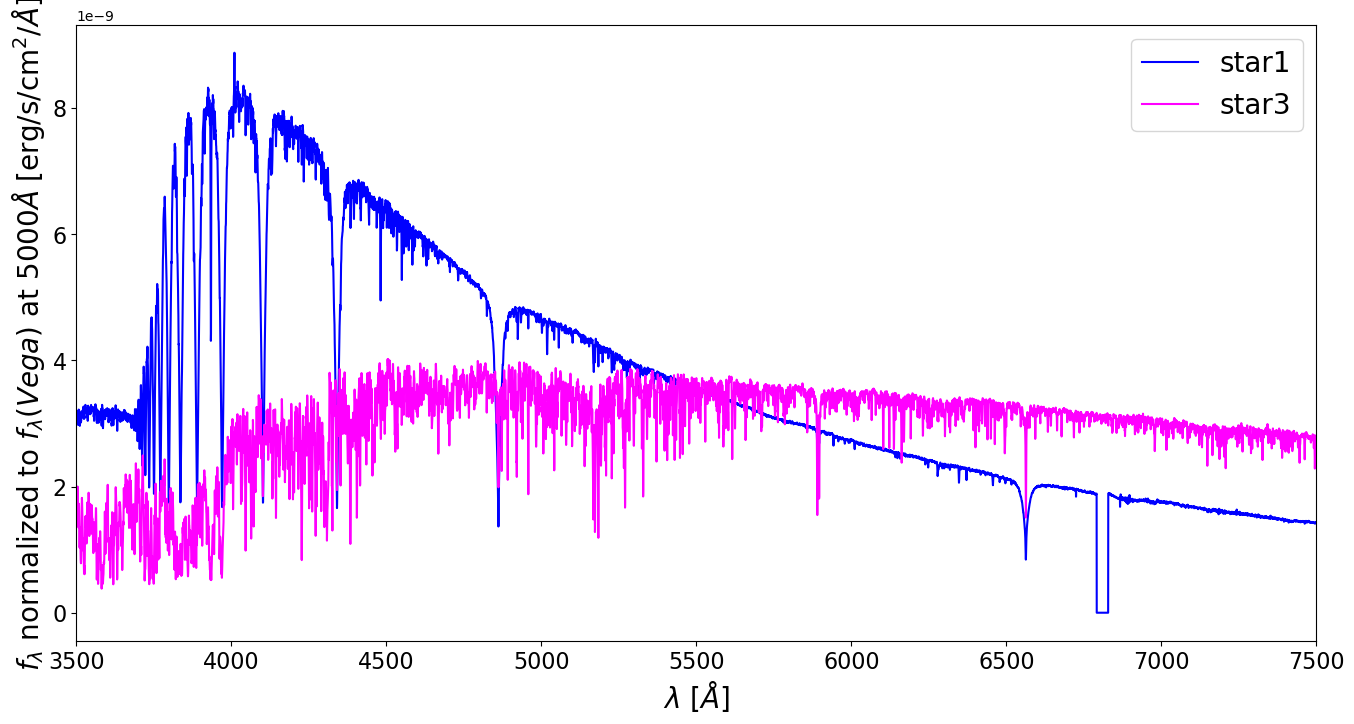

In [4]:
#this calls the function from above
starplot()
#this causes the plot to display
plt.show()

### Problem 4 (5 points)
Comment on the differences and similarities between the three spectra.  Write your answer in an empty markdown cell below this one. *Note: the strange dip in the blue spectrum at ~6800 is from the instrument and not the star.*

<font color='red'>The spectra have very different shapes.  Star 1 rises very rapidly in flux towards short wavelengths and then drops dramatically at about 3800 Angstroms.  Star 3 on the other hand is much flatter in flux and does not decline as steeply.  It does have a drop at around 4000 Angstroms, but not at the same wavelength as for Star 1. </font> 
    
<font color='red'>The absorption lines in star 1 are much deeper than in star 3, however there are many fewer of them.  The absorption lines in star 1 appear to coincide directly with the wavelenghts of lines in star 3, although those latter lines are weaker.  </font>

<font color='red'> It is hard to tell from this plot but it also appears that star 1 peaks at a shorter wavelength than star 3 and therefore probably is hotter </font>

## Measure the monochromatic flux density of each star at 4500 Angstroms

You will now need to find the closest flux point to the one at 4500 and 6500 Angstroms and print it out.  This will be the monochromatic flux density in $f_\lambda$.

I will start by showing you how to extract the $f_\lambda$ of star 1 at 4500 Anstroms

In [5]:
#these are the reference wavelengths in angstroms
lamref1 = 4500.0
lamref2 = 6500.0


#to select a given wavelength we will make a new array 
#that is filled with the absolute value of the difference between the reference wavelength 
#and our wavelength array.  
star1_difflam_ref1 = abs(star1['lambda'] - lamref1)

#now find the wavelength that is closest to lamref1 by using the 'argmin' function in python
#which returns the index that corresponds to the minimum value
minind_star1_difflam_ref1 = np.argmin(star1_difflam_ref1)

#now we can use this index number to find the wavelength and flux closest to the reference 
#wavelength by adding on a second index field, in which is inserted the index of the minimum wavelength 
#difference from the previous statement.
#we assign these values to two new variables.
flam_star1_lamref1 = star1['flam'][minind_star1_difflam_ref1]
star1_lamref1 = star1['lambda'][minind_star1_difflam_ref1]

#print('flam of star1 at', star1_lamref1, 'Angstroms = ', star1['flam'][minind_star1_difflam_ref1])
print(f'flam of star1 at {star1_lamref1:6.1f} Angstroms = {star1['flam'][minind_star1_difflam_ref1]:5.2e} erg/s/cm^2/Ang')


flam of star1 at 4499.8 Angstroms = 6.41e-09 erg/s/cm^2/Ang


### Problem 5 (15 points)
In the following code block you will need to write code that allows you to:
1. (5 points) retrieve flambda from star1 and 3 at 2 reference wavelengths of 4500 and 6500 Angstroms (I already showed you how to do this for star 1 at 4500 Anstroms);
2. (5 points) calculate fnu at each of these reference wavelengths for both stars;
3. (5 points) comment on the relative values at each wavelength.

To do part 1, I want you to make similar print statements for $f_\lambda$ for the second reference wavelength for star 1 and for both reference 
wavelengths for star 3.  Treat every star's wavelength array as different as you 
don't know if they all have the same length.

Also make sure you print them out in a way that is easy for me to understand.  You 
can use my code as a template.

You need to print out the units, here and for all numerical answers in all assignments, unless they are unitless.

This section might seem a bit long, but with the exception of the last calculations should just
be based on what I did above.  I will provide some small hints throughout.

In [6]:
#### Write code here for 5.1


#construct the wavelength difference array for all the star and reference wavelength combinations.
#star1_difflam_ref1 = abs(star1['lambda'] - lamref1)             #star 1, lambda 1
#star2_difflam_ref1 = abs(star2['lambda'] - lamref1)             #star 2, lambda 1
star3_difflam_ref1 = abs(star3['lambda'] - lamref1)             #star 3, lambda 1

star1_difflam_ref2 = abs(star1['lambda'] - lamref2)             #star 1, lambda 2
#star2_difflam_ref2 = abs(star2['lambda'] - lamref2)             #star 2, lambda 2
star3_difflam_ref2 = abs(star3['lambda'] - lamref2)             #star 3, lambda 2

#find the minimum value of this difference
#minind_star1_difflam_ref1 = np.argmin(star1_difflam_ref1)       #star 1, lambda 1
#minind_star2_difflam_ref1 = np.argmin(star2_difflam_ref1)       #star 2, lambda 1
minind_star3_difflam_ref1 = np.argmin(star3_difflam_ref1)       #star 3, lambda 1

minind_star1_difflam_ref2 = np.argmin(star1_difflam_ref2)       #star 1, lambda 2
#minind_star2_difflam_ref2 = np.argmin(star2_difflam_ref2)       #star 2, lambda 2
minind_star3_difflam_ref2 = np.argmin(star3_difflam_ref2)       #star 3, lambda 2

#find the wavelength at the minimum value of the difference
#star1_lamref1 = star1['lambda'][minind_star1_difflam_ref1]   #star 1, lambda 1
#star2_lamref1 = star2['lambda'][minind_star2_difflam_ref1]   #star 2, lambda 1
star3_lamref1 = star3['lambda'][minind_star3_difflam_ref1]   #star 3, lambda 1

star1_lamref2 = star1['lambda'][minind_star1_difflam_ref2]   #star 1, lambda 2
#star2_lamref2 = star2['lambda'][minind_star2_difflam_ref2]   #star 2, lambda 2
star3_lamref2 = star3['lambda'][minind_star3_difflam_ref2]   #star 3, lambda 2

#find the flux at that wavelength
#flam_star1_lamref1 = star1['flam'][minind_star1_difflam_ref1]   #star 1, lambda 1
#flam_star2_lamref1 = star2['flam'][minind_star2_difflam_ref1]   #star 2, lambda 1
flam_star3_lamref1 = star3['flam'][minind_star3_difflam_ref1]   #star 3, lambda 1

flam_star1_lamref2 = star1['flam'][minind_star1_difflam_ref2]   #star 1, lambda 2
#flam_star2_lamref2 = star2['flam'][minind_star2_difflam_ref2]   #star 2, lambda 2
flam_star3_lamref2 = star3['flam'][minind_star3_difflam_ref2]   #star 3, lambda 2


#now print out the values
print()
#print('flam of star1 at', star1_lamref1, 'Angstroms = ', flam_star1_lamref1)
#print('flam of star2 at', star2_lamref1, 'Angstroms = ', flam_star2_lamref1)
print(f'flam of star3 at {star3_lamref1:6.1f} Angstroms = {flam_star3_lamref1:5.2e} erg/s/cm^2/Ang')
print()
print(f'flam of star1 at {star1_lamref2:6.1f} Angstroms = {flam_star1_lamref2:5.2e} erg/s/cm^2/Ang')
#print('flam of star2 at', star2_lamref2, 'Angstroms = ', flam_star2_lamref2)
print(f'flam of star3 at {star3_lamref2:6.1f} Angstroms = {flam_star3_lamref2:5.2e} erg/s/cm^2/Ang')
#print('flam of star3 at', star3_lamref2, 'Angstroms = ', flam_star3_lamref2)

#as an internal check, verify to yourself that the wavelengths correspond closely 
#to the reference wavelengths and check your answers against the figure above




flam of star3 at 4499.8 Angstroms = 3.80e-09 erg/s/cm^2/Ang

flam of star1 at 6499.8 Angstroms = 2.14e-09 erg/s/cm^2/Ang
flam of star3 at 6499.8 Angstroms = 3.03e-09 erg/s/cm^2/Ang


now I want you to use the values of flambda and lambda to to compute fnu in erg/s/cms^2/Hz .
I want you to do this for star1 **and** star 3
For the conversion, if you choose you can adopt the same reference wavelength for each star
for each star at each reference wavelength.  
Print out the values so that I know which values are which.
in the formula, you use to get fnu, you need to make sure that the units of your answer make sense

In [7]:
#### Write code here for 5.2

#find the frequency at the reference wavelength
#convert lamref1 to meters and then to Hz
lamref1_m = lamref1 * 1.e-10
nu_ref1 = 3.e8 / lamref1_m

lamref2_m = lamref2 * 1.e-10
nu_ref2 = 3.e8 / lamref2_m

#convert using fnu = flam * c / nu^2
#remember that c needs to be in Angstroms for the units to work out
fnu_star1_lamref1 = flam_star1_lamref1 * (3.e8 * 1.e10) / nu_ref1**2
#fnu_star2_lamref1 = flam_star2_lamref1 * (3.e8 * 1.e10) / nu_ref1**2
fnu_star3_lamref1 = flam_star3_lamref1 * (3.e8 * 1.e10) / nu_ref1**2

#remember that c needs to be in Angstroms for the units to work out
fnu_star1_lamref2 = flam_star1_lamref2 * (3.e8 * 1.e10) / nu_ref2**2
#fnu_star2_lamref2 = flam_star2_lamref2 * (3.e8 * 1.e10) / nu_ref2**2
fnu_star3_lamref2 = flam_star3_lamref2 * (3.e8 * 1.e10) / nu_ref2**2

print()
print(f'fnu of star1 at {star1_lamref1:6.1f} Angstroms = {fnu_star1_lamref1:5.2e} erg/s/cm^2/Hz')
#print('fnu of star1 at', star1_lamref1, 'Angstroms = ', fnu_star1_lamref1)
#print('fnu of star2 at', star2_lamref1, 'Angstroms = ', fnu_star2_lamref1)
print(f'fnu of star3 at {star3_lamref1:6.1f} Angstroms = {fnu_star3_lamref1:5.2e} erg/s/cm^2/Hz')
#print('fnu of star3 at', star3_lamref1, 'Angstroms = ', fnu_star3_lamref1)
print()
print(f'fnu of star1 at {star1_lamref2:6.1f} Angstroms = {fnu_star1_lamref2:5.2e} erg/s/cm^2/Hz')
#print('fnu of star1 at', star1_lamref2, 'Angstroms = ', fnu_star1_lamref2)
#print('fnu of star2 at', star2_lamref2, 'Angstroms = ', fnu_star2_lamref2)
print(f'fnu of star3 at {star3_lamref2:6.1f} Angstroms = {fnu_star3_lamref2:5.2e} erg/s/cm^2/Hz')
#print('fnu of star3 at', star3_lamref2, 'Angstroms = ', fnu_star3_lamref2)
#----


fnu of star1 at 4499.8 Angstroms = 4.33e-20 erg/s/cm^2/Hz
fnu of star3 at 4499.8 Angstroms = 2.57e-20 erg/s/cm^2/Hz

fnu of star1 at 6499.8 Angstroms = 3.01e-20 erg/s/cm^2/Hz
fnu of star3 at 6499.8 Angstroms = 4.26e-20 erg/s/cm^2/Hz


### 5.3 Looking at the plot of the spectra above, comment on the relative rankings of flambda and fnu at both reference wavelengths.  Does the ranking correspond to your expectations?  Justify your answer.
<font color='red'> At 4500 Angstroms, star 1 is slightly brighter in $f_\lambda$.  At 6500 Angstroms, star 3 is brighter.  This is also true in $f_\nu$.  This makes sense as an object that is brighter in $f_\lambda$ at one wavelength must also be brighter in $f_\nu$ at the same wavelength.   </font>

<font color='red'> On the other hand, if I look at star 3 in $f_\lambda$ it is slightly brighter at 4500 Ang than at 6500 Ang but in $f_\nu$ it is fainter at the shorter wavelength.  Star 1 on the other hand is much brighter at 4500 Ang compared to 6500 Ang in $f_\lambda$ but is barely brighter when I compare the $f_\nu$ between the two wavelengths.</font>


### Estimate the color of the spectra using the filter curves
Now we will plot our filter curves on top of the spectra with an arbitrary normalization.  You will then estimate the color of each star in three different ways.  


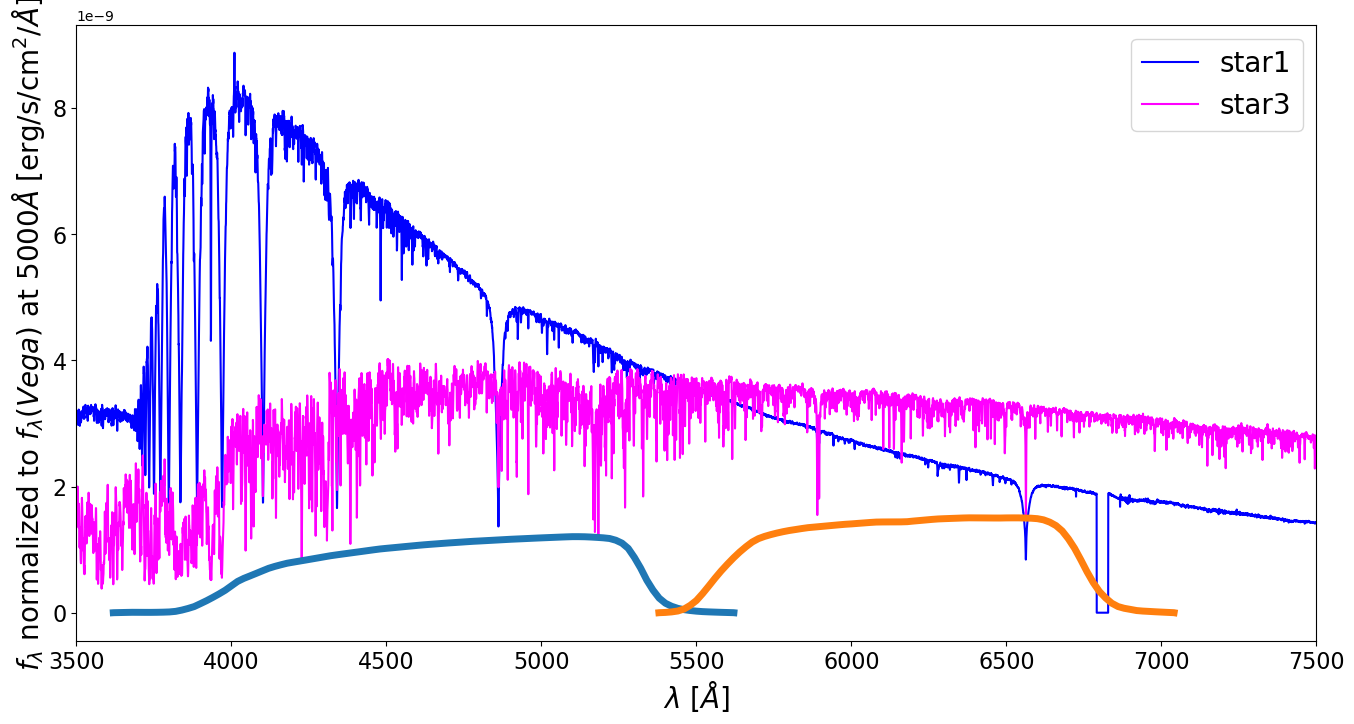

In [8]:
#This calls the plotting function from earlier in the code and plots the stars
starplot()

#this now reads in the filter traces and overplots them
#now read in "g" and "r" filter curves from speclite.  
gband = speclite.filters.load_filter('sdss2010-g')
rband = speclite.filters.load_filter('sdss2010-r')
#normalize the filter response curves so that they fits on our plot, 
#since they are usually plotted from 0 to 1.

#For speclite output, the values are referenced using the .wavelength and .response
#you can access individual gband.wavelength is an array that can be accessed using indices
#like gband.wavelength[22]
plt.plot(gband.wavelength,gband.response * 3.e-9,linewidth=5)
plt.plot(rband.wavelength,rband.response * 3.e-9,linewidth=5)

#this causes the plot to display
plt.show()


## Boolean arrays - A way to access a given set of elements in an array

This section provides some useful background that you may employ for exercise #6.2 below.

If you have an array, you can perform queries based on values of that array.  These queries return "Boolean arrays", which will contain True or False values depending on whether the element of the array meets the criteria.  You can then use these Boolean arrays to only access the value you would

In [9]:
#this example shows you how to create and use a boolean array witha single argument
a = np.array([1,2,3,4,5])           #create an array
#perform a query.
#I always end the the output of a Boolean query out with "flag" so that I know it's a 
#Boolean array
asmallflag = a < 4           

#you can see that only the first three elements of asmall are "True"
print('A boolean array that selects small a values:', asmallflag)

#now using 'abig' as an array of indices for 'a' you can print out only the elements of a 
#that meet your query, that is, those that have True indices
print('Only the elemens of a for which the query yielded a True:', a[asmallflag])

#Now let's make a second array with the same length as a
b = np.array(['aa','bb','cc','dd','ee'])

# in this case, b could be names of object in a table and a could be some value associated 
#with those objects.  Since they have the same length, same order, **and** refer to the same set of data
#we can apply the 'abig' Boolean array to find out which elements of b are selected when we 
#perform our query on a
print('Only the elements of b that were selected by the previous query:', b[asmallflag])

#that's pretty cool!  But wait, there's more
#you can also make Boolean arrays by combining different conditions.  You can do this two different
#wasy.  
#First, you can set up a single query with two conditions, each enclosed in ()
amidflag = (a>2) & (a<4)
print('The elements of a and b that meet the new criteria: ', a[amidflag], b[amidflag])

#but I can also make individual Boolean arrays and combine them with a logical AND (&) command.
#Only elements that are True in both input arrays are true in the output array
abigflag = a>2
amidflag2 = abigflag & asmallflag
print('The results of combining the two previous selections:',amidflag2, a[amidflag2])

#and finally, we can assign only the values that satisfy a boolean command to a new arraw.
#in this case, only values of a with True indicies in amidflag2 will be assigned to onlymidvalues
onlymidvalues = a[amidflag2]
print(onlymidvalues)

#in the exercise below, we will use this technique to print out the flux at a point
#on the spectrum with a given wavelength

A boolean array that selects small a values: [ True  True  True False False]
Only the elemens of a for which the query yielded a True: [1 2 3]
Only the elements of b that were selected by the previous query: ['aa' 'bb' 'cc']
The elements of a and b that meet the new criteria:  [3] ['cc']
The results of combining the two previous selections: [False False  True False False] [3]
[3]


### Problem 6 (15 points)
Using the plot above write two blocks of code.  
1. (5 points) Estimate by eye the central wavelength of each filter, using the plotted filter curves.  Note this is the central wavelength, not the peak wavelength.  Then use this wavelength as in the exercise above to determine 
    * fnu for each filter and each star
    * the AB magnitude for each filter and each star
    * the g-r color for each star
    * make sure all of these are clearly printed out.
    * In the textbox following the code block discuss your answers and if they make sense
2. (5 points) Now come up with your own method of estimating the fnu using the full filter curve.  There are multiple ways to do this.  If you don't have a lot of computing experience, you should try an approximation for the filter shape that will allow you to better compute the average flux within the filter (*note the filter curves are fairly flat with sharp edges*).  If you want to try something more challenging, you can code up the full filter integral. Regardless of your choice, with that value of fnu, compute the AB magnitudes and filters as in the exercise above. 
    * It's great if you want to integrate the filter curve, but it is more complex because the filter and spectrum have different wavelength spacing and you have to interpolate the filter curve to match the spectra wavelength spacing.  Let me know if you're interested and I can help you do this.
3. execute my block of code that computes the correct answers using the speclite package.  This package actually integrates the filter curves.  **Note that you will not get credit for just matching the correct answer.  I am including it so that you can comment on any differences in the following part.  I will grade you on how you get your answer, not whether your answer matches mine.**
4. (5 points) Compare your colors with the plots of the spectra and comment on whether they make sense. .  

In [10]:
#### Write code here for 6.1

#put your estimate for the central wavelength here
### leave
lamrefg = 4686.
lamrefr = 6165.
#fnu for each filter and star
#your calculations
star1_difflam_refg = abs(star1['lambda'] - lamrefg)
star1_difflam_refr = abs(star1['lambda'] - lamrefr)

star3_difflam_refg = abs(star3['lambda'] - lamrefg)
star3_difflam_refr = abs(star3['lambda'] - lamrefr)

#now find the wavelength that is closest to lamref1 by using the 'argmin' function in python
#which returns the index that corresponds to the minimum value
minind_star1_difflam_refg = np.argmin(star1_difflam_refg)
minind_star1_difflam_refr = np.argmin(star1_difflam_refr)

minind_star3_difflam_refg = np.argmin(star3_difflam_refg)
minind_star3_difflam_refr = np.argmin(star3_difflam_refr)

#now we can use this number to find the wavelength and flux closest to the reference 
#wavelength by adding on a second index field
#we assign these values to two new variables.
### leave
flam_star1_lamrefg = star1['flam'][minind_star1_difflam_refg]
flam_star1_lamrefr = star1['flam'][minind_star1_difflam_refr]

flam_star3_lamrefg = star3['flam'][minind_star3_difflam_refg]
flam_star3_lamrefr = star3['flam'][minind_star3_difflam_refr]

###not leave
#the frequency corresponding to the reference wavelengths
lamrefg_m = lamrefg * 1.e-10
nu_refg = 3.e8 / lamrefg_m

lamrefr_m = lamrefr * 1.e-10
nu_refr = 3.e8 / lamrefr_m

#convert using fnu = flam * c / nu^2
#remember that c needs to be in Angstroms for the units to work out
###leave
fnu_star1_gband = flam_star1_lamrefg * (3.e8 * 1.e10) / nu_refg**2
fnu_star3_gband = flam_star3_lamrefg * (3.e8 * 1.e10) / nu_refg**2

#remember that c needs to be in Angstroms for the units to work out
fnu_star1_rband = flam_star1_lamrefr * (3.e8 * 1.e10) / nu_refr**2
fnu_star3_rband = flam_star3_lamrefr * (3.e8 * 1.e10) / nu_refr**2


#print your fnu's here with the following format
print(f'fnu of star1 at the g-band = {fnu_star1_gband:5.2e} erg/s/cm^2/Hz')
print(f'fnu of star1 at the r-band = {fnu_star1_rband:5.2e} erg/s/cm^2/Hz')
print(f'fnu of star3 at the g-band = {fnu_star3_gband:5.2e} erg/s/cm^2/Hz')
print(f'fnu of star3 at the r-band = {fnu_star3_rband:5.2e} erg/s/cm^2/Hz')


#AB mag for each filter and star
#your calculations
###leave
ABmag_star1_gband = -2.5 * np.log10(fnu_star1_gband) - 48.60
ABmag_star1_rband = -2.5 * np.log10(fnu_star1_rband) - 48.60
ABmag_star3_gband = -2.5 * np.log10(fnu_star3_gband) - 48.60
ABmag_star3_rband = -2.5 * np.log10(fnu_star3_rband) - 48.60

#print your AB mags here with the following format
print(f'AB mag of star1 at the g-band = {ABmag_star1_gband:4.2f}')
print(f'AB mag of star1 at the r-band = {ABmag_star1_rband:4.2f}')
print(f'AB mag of star3 at the g-band = {ABmag_star3_gband:4.2f}')
print(f'AB mag of star3 at the r-band = {ABmag_star3_rband:4.2f}')

#g-r color for each star
#your calculations

gr_star1 =ABmag_star1_gband - ABmag_star1_rband
gr_star3 = ABmag_star3_gband - ABmag_star3_rband

#print your colors here with the following format
print(f'g-r color of star1 = {gr_star1:4.2f}')
print(f'g-r color of star3 = {gr_star3:4.2f}')


fnu of star1 at the g-band = 4.14e-20 erg/s/cm^2/Hz
fnu of star1 at the r-band = 3.19e-20 erg/s/cm^2/Hz
fnu of star3 at the g-band = 2.55e-20 erg/s/cm^2/Hz
fnu of star3 at the r-band = 4.14e-20 erg/s/cm^2/Hz
AB mag of star1 at the g-band = -0.14
AB mag of star1 at the r-band = 0.14
AB mag of star3 at the g-band = 0.38
AB mag of star3 at the r-band = -0.14
g-r color of star1 = -0.28
g-r color of star3 = 0.52


For part 6.2, I won't tell you what to do.  I want you to come up with your own way.  The way I describe below is what I consider to the be next most sophisticated treatement.  It is to assume that the filter response is constant between two wavelengths and to just take the average of the flux between those two wavelengths using a Boolean Array to select the appropriate flux values.

There are other more sophisticated ways and in the answer key I will provide the right answer against which you can compare yours.

In [11]:
#### Write code here for 6.2

#From looking at the plot, I am selecting a range of wavelengths that cover the areas of 
#high transmission in each filter.  In each array the first number is the lower limit
#and the second number the higher limit
lamgarr = np.array([4100.,5250.])
lamrarr = np.array([5600.,6600.])

#now find the range of wavelengths that are within this range
star1_lamg_flag = (star1['lambda'] > lamgarr[0]) & (star1['lambda'] < lamgarr[1]) 
star1_lamr_flag = (star1['lambda'] > lamrarr[0]) & (star1['lambda'] < lamrarr[1]) 

star3_lamg_flag = (star3['lambda'] > lamgarr[0]) & (star3['lambda'] < lamgarr[1]) 
star3_lamr_flag = (star3['lambda'] > lamrarr[0]) & (star3['lambda'] < lamrarr[1]) 

#now convert every flam to fnu and take the average over that wavelength range
#convert wavelengths to angstroms 
star1_lam_m = star1['lambda'] * 1.e-10
star3_lam_m = star3['lambda'] * 1.e-10
#compute frequency
star1_nu = 3.e8 / star1_lam_m
star3_nu = 3.e8 / star3_lam_m

#now compute fnu at every wavelength, but using the nu values for every wavelength.
#I could have rewritten this in terms of lambda instead but wanted to stay consistent with 
#what we did in class. 
#As we learned in the intro task, you can perform arithmetic operations on whole arrays
#which I am doing here.
fnu_star1 = star1['flam'] * (3.e8 * 1.e10) / star1_nu**2
fnu_star3 = star3['flam'] * (3.e8 * 1.e10) / star3_nu**2

#now that I have fnu arrays I can apply the Boolean array to find the average of all the 
#fnu values in the appropriate wavelength range.  I can do this by passing the fnu array
#indexed by the boolean array to the np.average() function
fnu_star1_gband = np.average(fnu_star1[star1_lamg_flag])
fnu_star1_rband = np.average(fnu_star1[star1_lamr_flag])

fnu_star3_gband = np.average(fnu_star3[star3_lamg_flag])
fnu_star3_rband = np.average(fnu_star3[star3_lamr_flag])

#your calculations
###leave
#fnu_star1_gband = 
#fnu_star1_rband = 
#fnu_star3_gband = 
#fnu_star3_rband = 

#print your fnu's here with the following format
print(f'fnu of star1 at the g-band = {fnu_star1_gband:5.2e} erg/s/cm^2/Hz')
print(f'fnu of star1 at the r-band = {fnu_star1_rband:5.2e} erg/s/cm^2/Hz')
print(f'fnu of star3 at the g-band = {fnu_star3_gband:5.2e} erg/s/cm^2/Hz')
print(f'fnu of star3 at the r-band = {fnu_star3_rband:5.2e} erg/s/cm^2/Hz')

#AB mag for each filter and star
#your calculations

#print your AB mags here with the following format
ABmag_star1_gband = -2.5 * np.log10(fnu_star1_gband) - 48.60
ABmag_star1_rband = -2.5 * np.log10(fnu_star1_rband) - 48.60
ABmag_star3_gband = -2.5 * np.log10(fnu_star3_gband) - 48.60
ABmag_star3_rband = -2.5 * np.log10(fnu_star3_rband) - 48.60

#print your AB mags here with the following format
print(f'AB mag of star1 at the g-band = {ABmag_star1_gband:4.2f}')
print(f'AB mag of star1 at the r-band = {ABmag_star1_rband:4.2f}')
print(f'AB mag of star3 at the g-band = {ABmag_star3_gband:4.2f}')
print(f'AB mag of star3 at the r-band = {ABmag_star3_rband:4.2f}')

#g-r color for each star
#your calculations

gr_star1 =ABmag_star1_gband - ABmag_star1_rband
gr_star3 = ABmag_star3_gband - ABmag_star3_rband

#print your colors here with the following format
print(f'g-r color of star1 = {gr_star1:4.2f}')
print(f'g-r color of star3 = {gr_star3:4.2f}')


fnu of star1 at the g-band = 3.96e-20 erg/s/cm^2/Hz
fnu of star1 at the r-band = 3.18e-20 erg/s/cm^2/Hz
fnu of star3 at the g-band = 2.36e-20 erg/s/cm^2/Hz
fnu of star3 at the r-band = 4.12e-20 erg/s/cm^2/Hz
AB mag of star1 at the g-band = -0.09
AB mag of star1 at the r-band = 0.14
AB mag of star3 at the g-band = 0.47
AB mag of star3 at the r-band = -0.14
g-r color of star1 = -0.24
g-r color of star3 = 0.60


## Check your work

The code below derives magnitudes and colors using the full filter convolution using speclite.  This takes into account both the full filter shape and the full spectrum.  You will just need to execute this code and compare to your answers in 6.3.


In [12]:
#we need to create "validated" wavelength arrays that conform to the 
#characteristics needed as input by speclite
#we use the units module to assign specific units to all wavelength and fluxes, as 
#speclite needs this to run properly.
star1lam = speclite.filters.validate_wavelength_array(star1['lambda']*u.AA)
star3lam = speclite.filters.validate_wavelength_array(star3['lambda']*u.AA)

#specify the flux unit of the input flux of our stars using the astropy units package
#these units will be associated with any number they are multiplied by.
fluxunit = u.erg/u.s/u.cm**2/u.AA

#these are useful speclite built in functions that
#1. integrate the spectrum over the filter curve
#2. divide it by the integral of just the filter curve, thus performing an average
#of the spectrum weighted by the filter curve 
#3. convert the average flux to fnu
#4. compute the AB magnitude
ABmag_star1_gband = gband.get_ab_magnitude(star1['flam']*fluxunit,wavelength=star1lam*u.AA)
ABmag_star1_rband = rband.get_ab_magnitude(star1['flam']*fluxunit,wavelength=star1lam*u.AA)

ABmag_star3_gband = gband.get_ab_magnitude(star3['flam']*fluxunit,wavelength=star3lam*u.AA)
ABmag_star3_rband = rband.get_ab_magnitude(star3['flam']*fluxunit,wavelength=star3lam*u.AA)

print(f'AB mag of star1 at the g-band = {ABmag_star1_gband:4.2f}')
print(f'AB mag of star1 at the r-band = {ABmag_star1_rband:4.2f}')
print(f'AB mag of star3 at the g-band = {ABmag_star3_gband:4.2f}')
print(f'AB mag of star3 at the r-band = {ABmag_star3_rband:4.2f}')

gr_star1 =ABmag_star1_gband - ABmag_star1_rband
gr_star3 = ABmag_star3_gband - ABmag_star3_rband

#print your colors here with the following format
print(f'g-r color of star1 = {gr_star1:4.2f}')
print(f'g-r color of star3 = {gr_star3:4.2f}')


AB mag of star1 at the g-band = -0.08
AB mag of star1 at the r-band = 0.16
AB mag of star3 at the g-band = 0.47
AB mag of star3 at the r-band = -0.15
g-r color of star1 = -0.24
g-r color of star3 = 0.62


### 6.3 Comment on how the colors compare to the spectra in the plot and to the differences between your two techniques.  Also compare to the correct answer given in the last cell.  Discuss why your techniques might have given different answers or the same.

<font color='red'> The colors between my estimates for 6.1 and 6.2 aren't that different but the colors for 6.2 are definitely closer to the "right" answer.  The same is true of the AB magnitudes.  My assumption that the filters were flat isn't actually that bad for these filter shapes.</font>

### Reflection statement (required for credit on assignment)

You need to provide a statement on whether you used AI, how you used AI, what the advantages and disadvantages were.  I also want you to write what approach you use to solve the problem.  I am looking for a 1-2 short paragraphs here.